## ⚠️ IMPORTANT: Before Running

### Required folder structure in Google Drive:
```
MyDrive/images/
  ├── cassiopeia/
  ├── crux/
  ├── cygnus/
  ├── gemini/
  ├── leo/
  ├── orion/
  └── ursa_major/
```
Access images here: [Constellation Images](https://drive.google.com/drive/folders/1q4SkFq9ItMgH9Xq33CHmbNABI9_7iljr?usp=sharing)


## Imports and Environment Setup

In [ ]:
import os
import shutil
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image as PILImage
from IPython.display import display
from google.colab import drive

drive.mount('/content/drive')
print(f"TensorFlow Version: {tf.__version__}")


Mounted at /content/drive
TensorFlow Version: 2.19.0


## Project Configuration

In [ ]:
# ── Directory paths ──────────────────────────────────────────
DATA_DIR   = '/content/drive/MyDrive/images'
TRAIN_DIR  = '/content/train'
VAL_DIR    = '/content/validation'
TEST_DIR   = '/content/test'          # NEW: held-out test set
MODEL_DIR  = '/content/drive/MyDrive/models'

# ── Hyperparameters ───────────────────────────────────────────
IMG_HEIGHT    = 224
IMG_WIDTH     = 224
BATCH_SIZE    = 16
EPOCHS        = 50
LEARNING_RATE = 0.0005

# ── Split ratios (must sum to 1.0) ────────────────────────────
TRAIN_SPLIT = 0.70   # 70% training
VAL_SPLIT   = 0.15   # 15% validation
TEST_SPLIT  = 0.15   # 15% held-out test  ← NEW

# ── Reproducibility ───────────────────────────────────────────
RANDOM_SEED = 42     # fixes all shuffles for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Cross-validation / multi-seed settings ────────────────────
N_FOLDS     = 5      # 5-fold stratified CV
N_SEEDS     = 5      # number of different seeds for final variance estimate

os.makedirs(MODEL_DIR, exist_ok=True)
print("Configuration initialized.")
print(f"  Split  →  train {TRAIN_SPLIT:.0%} | val {VAL_SPLIT:.0%} | test {TEST_SPLIT:.0%}")
print(f"  Seed   →  {RANDOM_SEED}")
print(f"  CV folds: {N_FOLDS}  |  Multi-seed runs: {N_SEEDS}")


Configuration initialized.
  Split  →  train 70% | val 15% | test 15%
  Seed   →  42
  CV folds: 5  |  Multi-seed runs: 5


## Utility Functions — Image Preprocessing

In [ ]:
def convert_all_images_to_jpg(data_dir):
    """
    Standardizes dataset by converting non-JPG images (WebP, PNG, etc.)
    to JPEG format. Transparency channels are composited onto white background.
    """
    if not os.path.exists(data_dir):
        print(f"Error: Directory not found at {data_dir}")
        return

    total_converted = 0
    folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
    print("Initiating image format conversion...")

    for folder in folders:
        folder_path = os.path.join(data_dir, folder)
        image_files = [f for f in os.listdir(folder_path)
                       if f.lower().endswith(('.webp', '.png', '.bmp', '.gif'))]

        for img_file in image_files:
            try:
                original_path = os.path.join(folder_path, img_file)
                jpg_path = os.path.join(folder_path, img_file.rsplit('.', 1)[0] + '.jpg')
                img = PILImage.open(original_path)

                # Handle transparency channels
                if img.mode in ('RGBA', 'LA', 'P'):
                    background = PILImage.new('RGB', img.size, (255, 255, 255))
                    if img.mode == 'P':
                        img = img.convert('RGBA')
                    background.paste(img, mask=img.split()[-1] if img.mode == 'RGBA' else None)
                    img = background
                elif img.mode != 'RGB':
                    img = img.convert('RGB')

                img.save(jpg_path, 'JPEG', quality=95)
                os.remove(original_path)
                total_converted += 1
            except Exception as e:
                print(f"  Failed to convert {img_file}: {e}")

    print(f"Conversion complete. Total converted: {total_converted}")

convert_all_images_to_jpg(DATA_DIR)


Initiating image format conversion...
Conversion complete. Total converted: 0


## Dataset Analysis

Classes found  : 7
Total images   : 202
Expected split : train ~141 | val ~30 | test ~30

  cassiopeia      30 images
  crux            25 images
  cygnus          30 images
  gemini          28 images
  leo             30 images
  orion           30 images
  ursa_major      29 images


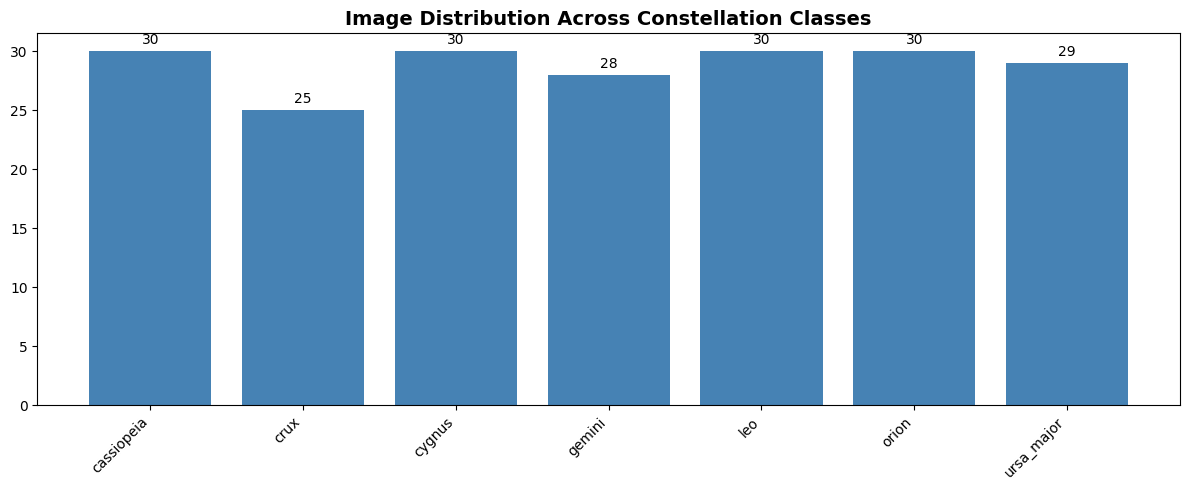

In [ ]:
if os.path.exists(DATA_DIR):
    image_counts = {
        cls: len([f for f in os.listdir(os.path.join(DATA_DIR, cls))
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for cls in sorted(os.listdir(DATA_DIR))
        if os.path.isdir(os.path.join(DATA_DIR, cls))
    }
    total_images = sum(image_counts.values())

    print(f"Classes found  : {len(image_counts)}")
    print(f"Total images   : {total_images}")
    print(f"Expected split : train ~{int(total_images*TRAIN_SPLIT)} "
          f"| val ~{int(total_images*VAL_SPLIT)} "
          f"| test ~{int(total_images*TEST_SPLIT)}")
    print()
    for cls, count in image_counts.items():
        print(f"  {cls:<15} {count} images")

    plt.figure(figsize=(12, 5))
    bars = plt.bar(image_counts.keys(), image_counts.values(), color='steelblue')
    plt.title('Image Distribution Across Constellation Classes', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.bar_label(bars, padding=3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Could not find directory {DATA_DIR}")


## Data Visualization — Sample Images

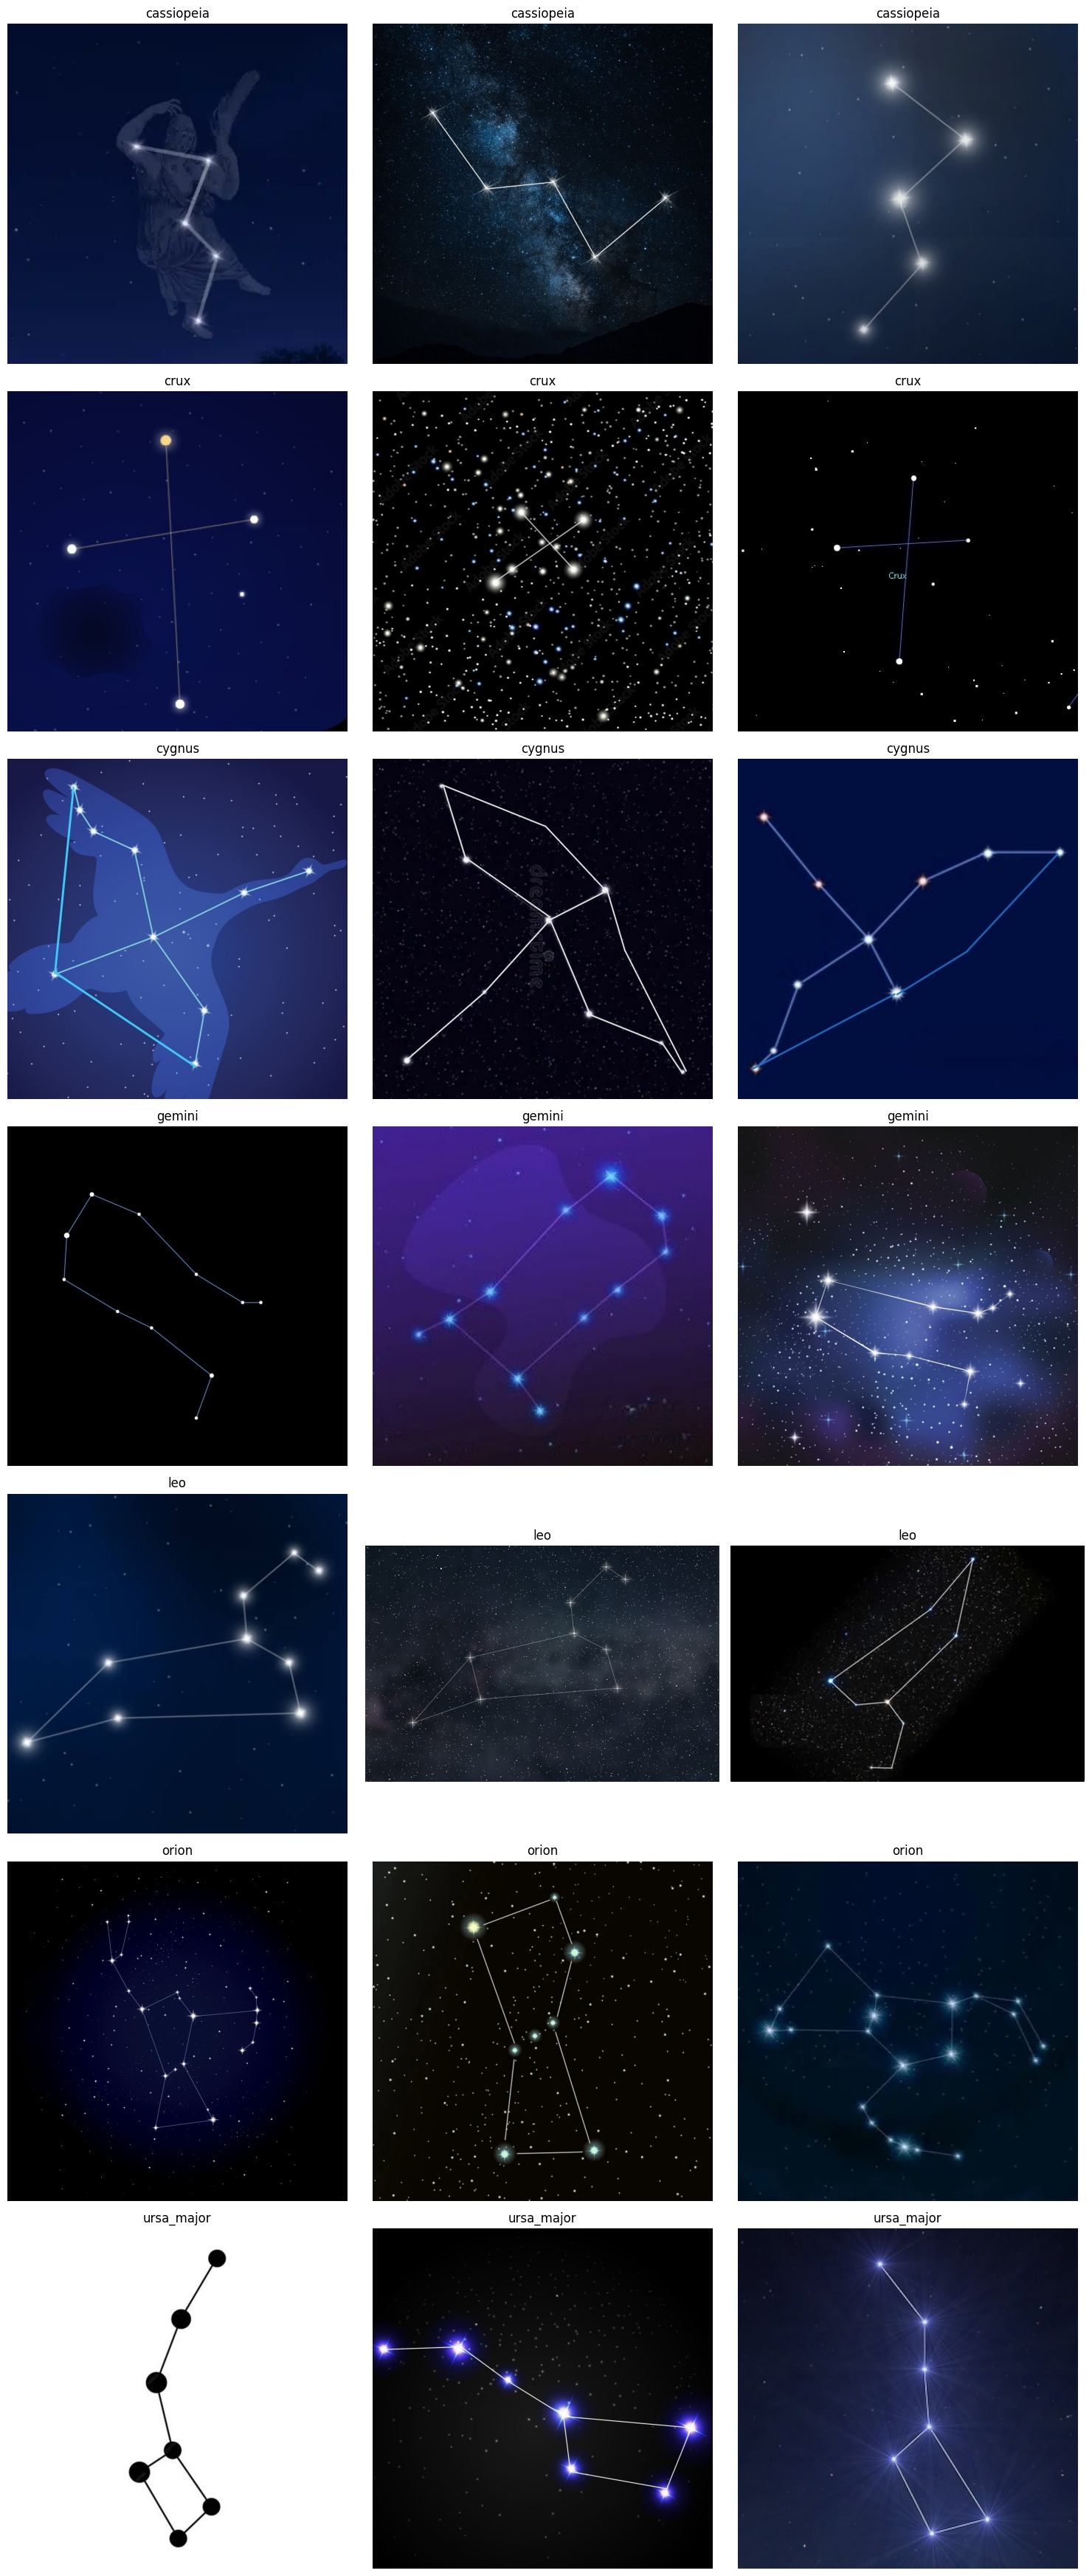

In [ ]:
def plot_sample_images(data_dir, num_samples=3):
    """Displays sample images from each constellation class."""
    classes = sorted([f for f in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, f))])
    plt.figure(figsize=(15, 5 * len(classes)))
    for idx, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        img_names = [f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg'))][:num_samples]
        for i, img_name in enumerate(img_names):
            plt.subplot(len(classes), num_samples, idx * num_samples + i + 1)
            img = load_img(os.path.join(cls_path, img_name))
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images(DATA_DIR)


## 3-Way Data Split — Train / Validation / Test


In [ ]:
def split_data_three_way(source_dir, train_dir, val_dir, test_dir,
                         train_ratio=0.70, val_ratio=0.15, seed=42):
    """
    Splits image data into train / validation / test sets per class
    using a fixed random seed for reproducibility.

    Args:
        source_dir  : Root directory with one sub-folder per class.
        train_dir   : Destination for training images.
        val_dir     : Destination for validation images.
        test_dir    : Destination for held-out test images.
        train_ratio : Fraction for training (default 0.70).
        val_ratio   : Fraction for validation (default 0.15).
                      Remaining fraction goes to test.
        seed        : Random seed for reproducible shuffles.
    """
    for d in [train_dir, val_dir, test_dir]:
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d)

    rng = np.random.default_rng(seed)   # seeded RNG — reproducible every run
    classes = [f for f in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, f))]

    print(f"Splitting data (seed={seed}) →  "
          f"train {train_ratio:.0%} | val {val_ratio:.0%} | "
          f"test {1-train_ratio-val_ratio:.0%}\n")

    split_summary = {}

    for cls in classes:
        for d in [train_dir, val_dir, test_dir]:
            os.makedirs(os.path.join(d, cls), exist_ok=True)

        src = os.path.join(source_dir, cls)
        imgs = sorted([f for f in os.listdir(src)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        rng.shuffle(imgs)   # deterministic shuffle per class

        n_train = int(len(imgs) * train_ratio)
        n_val   = int(len(imgs) * val_ratio)

        train_imgs = imgs[:n_train]
        val_imgs   = imgs[n_train:n_train + n_val]
        test_imgs  = imgs[n_train + n_val:]

        for img in train_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(train_dir, cls, img))
        for img in val_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(val_dir, cls, img))
        for img in test_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(test_dir, cls, img))

        split_summary[cls] = {
            'train': len(train_imgs),
            'val': len(val_imgs),
            'test': len(test_imgs)
        }
        print(f"  {cls:<15} train={len(train_imgs)}  val={len(val_imgs)}  test={len(test_imgs)}")

    total_train = sum(v['train'] for v in split_summary.values())
    total_val   = sum(v['val']   for v in split_summary.values())
    total_test  = sum(v['test']  for v in split_summary.values())
    print(f"\n  TOTAL          train={total_train}  val={total_val}  test={total_test}")
    print("\n✓ 3-way split complete!")
    return split_summary

split_summary = split_data_three_way(
    DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
    train_ratio=TRAIN_SPLIT,
    val_ratio=VAL_SPLIT,
    seed=RANDOM_SEED
)


Splitting data (seed=42) →  train 70% | val 15% | test 15%

  orion           train=21  val=4  test=5
  ursa_major      train=20  val=4  test=5
  cassiopeia      train=21  val=4  test=5
  crux            train=17  val=3  test=5
  cygnus          train=21  val=4  test=5
  leo             train=21  val=4  test=5
  gemini          train=19  val=4  test=5

  TOTAL          train=140  val=27  test=35

✓ 3-way split complete!


## Data Augmentation


In [ ]:
# Training generator — with domain-aware augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,          # constellations appear rotated by observer latitude
    width_shift_range=0.2,      # off-center handheld framing
    height_shift_range=0.2,
    shear_range=0.2,            # perspective distortion from non-zenith angles
    zoom_range=0.2,             # variable focal lengths
    horizontal_flip=True,       # mirror images preserve pattern structure
    brightness_range=[0.6, 1.4],# variable sky luminance / light pollution
    fill_mode='nearest'
)

# Validation and test generators — rescaling only, NO augmentation
eval_datagen = ImageDataGenerator(rescale=1./255)

print("Augmentation configured for training only.")
print("Validation and test generators: rescale only (no augmentation).")


Augmentation configured for training only.
Validation and test generators: rescale only (no augmentation).


## Load Data Generators

In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=RANDOM_SEED
)

validation_generator = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Test generator — never shuffled, never augmented
test_generator = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names  = list(train_generator.class_indices.keys())
num_classes  = len(class_names)

print(f"Classes ({num_classes}): {class_names}")
print(f"Training   : {train_generator.samples} images")
print(f"Validation : {validation_generator.samples} images")
print(f"Test       : {test_generator.samples} images  ← held out until final evaluation")


Found 140 images belonging to 7 classes.
Found 27 images belonging to 7 classes.
Found 35 images belonging to 7 classes.
Classes (7): ['cassiopeia', 'crux', 'cygnus', 'gemini', 'leo', 'orion', 'ursa_major']
Training   : 140 images
Validation : 27 images
Test       : 35 images  ← held out until final evaluation


## Augmentation Visualization

Showing augmentations for: cygnus / cyg9.jpg


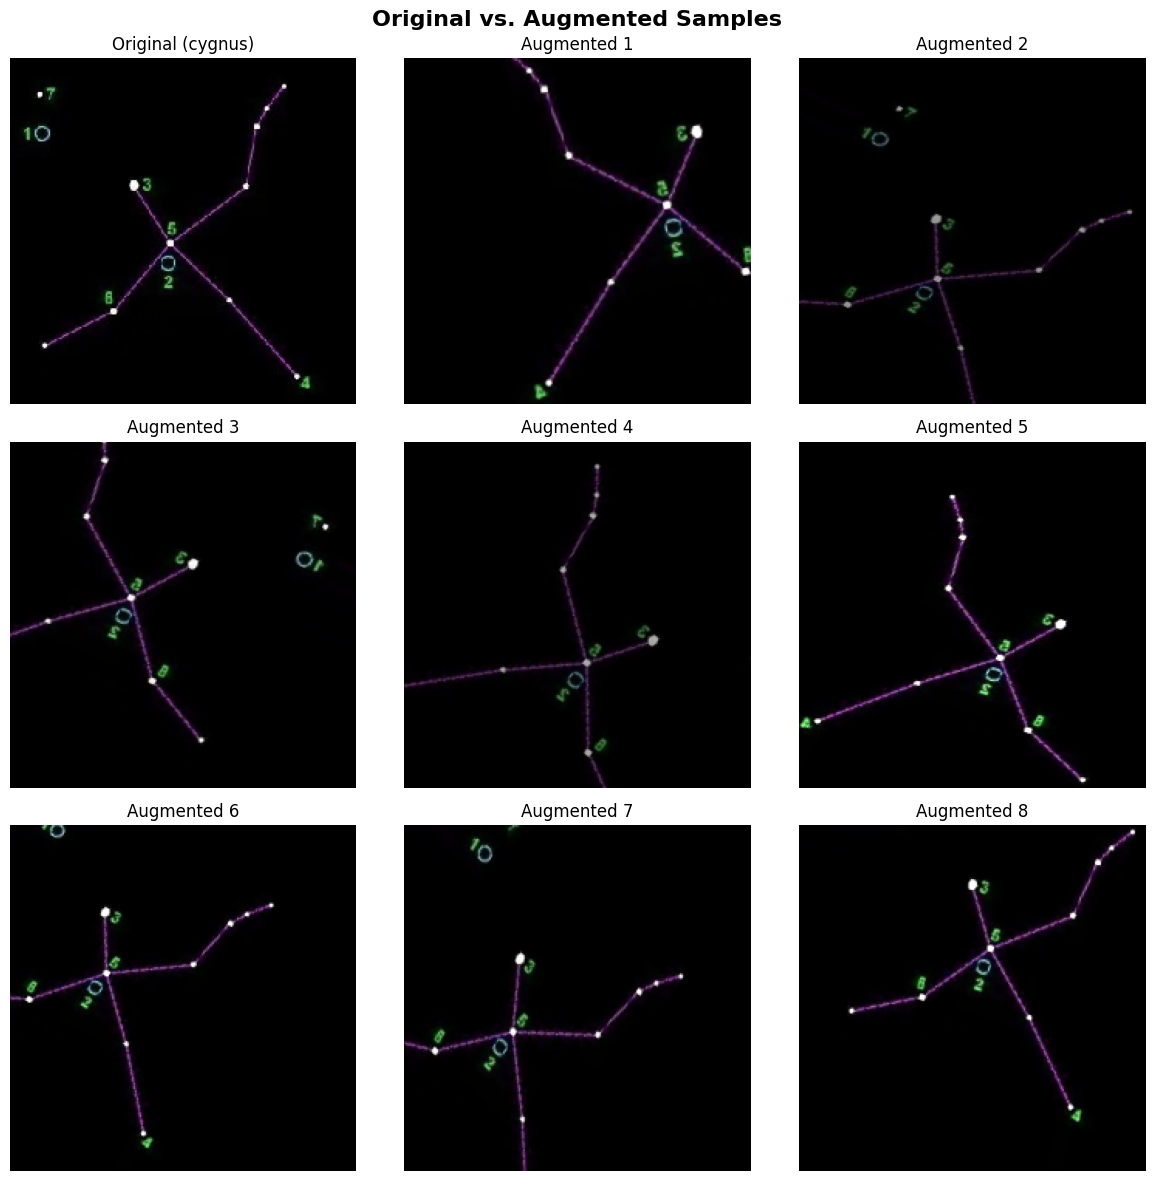

In [ ]:
random_cls = random.choice(os.listdir(TRAIN_DIR))
random_img = random.choice(os.listdir(os.path.join(TRAIN_DIR, random_cls)))
img_path   = os.path.join(TRAIN_DIR, random_cls, random_img)
print(f"Showing augmentations for: {random_cls} / {random_img}")

img       = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = np.expand_dims(image.img_to_array(img), axis=0)

plt.figure(figsize=(12, 12))
plt.subplot(3, 3, 1)
plt.imshow(img_array[0] / 255.0)
plt.title(f"Original ({random_cls})")
plt.axis('off')

aug_iter = train_datagen.flow(img_array, batch_size=1, seed=RANDOM_SEED)
for i in range(2, 10):
    plt.subplot(3, 3, i)
    plt.imshow(next(aug_iter)[0])
    plt.title(f"Augmented {i-1}")
    plt.axis('off')

plt.suptitle('Original vs. Augmented Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Model Definitions — MobileNetV2 and Baseline CNN

Two models are defined:

1. **MobileNetV2 (transfer learning)** — the main model. ImageNet weights are
   frozen; only the classification head is trained.
2. **Baseline CNN** — a simple 3-layer CNN trained from scratch with the same
   input size. This gives a reference point so the paper can quantify how much
   transfer learning helps.


In [ ]:
def create_mobilenetv2(num_classes, learning_rate=0.001):
    """
    MobileNetV2 transfer learning model.
    Base layers are frozen. Only the Dense head is trained.
    """
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    base.trainable = False   # freeze all ImageNet weights

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def create_baseline_cnn(num_classes, learning_rate=0.001):
    """
    Simple 3-layer CNN trained from scratch — used as comparison baseline.
    Deliberately lightweight to show the advantage of transfer learning.
    """
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def get_callbacks():
    """Returns EarlyStopping + ReduceLROnPlateau callbacks."""
    early_stop = EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    )
    return [early_stop, reduce_lr]


# Quick sanity check
m = create_mobilenetv2(num_classes)
print("MobileNetV2 head — trainable params:", m.count_params())
m_b = create_baseline_cnn(num_classes)
print("Baseline CNN   — trainable params:", m_b.count_params())
del m, m_b


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 head — trainable params: 2587719
Baseline CNN   — trainable params: 128071


## 5-Fold Stratified Cross-Validation


In [ ]:
from sklearn.model_selection import StratifiedKFold

# ── Collect all image paths and labels from TRAIN + VAL directories ──────────
# We re-pool train+val for CV (test is still untouched).
# CV is done only on the non-test data.

def collect_paths_labels(directories):
    """Returns (paths, labels) lists from one or more directory roots."""
    paths, labels = [], []
    # Get sorted class list from first directory
    classes = sorted([c for c in os.listdir(directories[0])
                      if os.path.isdir(os.path.join(directories[0], c))])
    class_to_idx = {c: i for i, c in enumerate(classes)}

    for root_dir in directories:
        for cls in classes:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    paths.append(os.path.join(cls_dir, fname))
                    labels.append(class_to_idx[cls])
    return np.array(paths), np.array(labels)

all_paths, all_labels = collect_paths_labels([TRAIN_DIR, VAL_DIR])
print(f"CV pool: {len(all_paths)} images across {len(np.unique(all_labels))} classes")
print(f"Class distribution: { {class_names[i]: int(np.sum(all_labels==i)) for i in range(num_classes)} }")


def run_fold(fold_idx, train_idx, val_idx, model_fn, seed):
    """
    Trains one model on a single fold.
    Writes fold images to temp directories, trains, and returns val accuracy.
    """
    fold_train_dir = f'/content/cv_fold_{fold_idx}_train'
    fold_val_dir   = f'/content/cv_fold_{fold_idx}_val'

    # Build fold directories
    for d in [fold_train_dir, fold_val_dir]:
        if os.path.exists(d): shutil.rmtree(d)
        for cls in class_names:
            os.makedirs(os.path.join(d, cls), exist_ok=True)

    for idx in train_idx:
        cls = class_names[all_labels[idx]]
        shutil.copy2(all_paths[idx], os.path.join(fold_train_dir, cls, os.path.basename(all_paths[idx])))
    for idx in val_idx:
        cls = class_names[all_labels[idx]]
        shutil.copy2(all_paths[idx], os.path.join(fold_val_dir, cls, os.path.basename(all_paths[idx])))

    # Generators
    fold_train_gen = train_datagen.flow_from_directory(
        fold_train_dir, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=seed
    )
    fold_val_gen = eval_datagen.flow_from_directory(
        fold_val_dir, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=False
    )

    tf.random.set_seed(seed)
    np.random.seed(seed)

    fold_model = model_fn(num_classes, LEARNING_RATE)

    class_w = compute_class_weight(
        'balanced',
        classes=np.unique(fold_train_gen.classes),
        y=fold_train_gen.classes
    )
    cw_dict = dict(enumerate(class_w))

    fold_model.fit(
        fold_train_gen,
        epochs=EPOCHS,
        validation_data=fold_val_gen,
        class_weight=cw_dict,
        callbacks=get_callbacks(),
        verbose=0
    )

    fold_val_gen.reset()
    preds = np.argmax(fold_model.predict(fold_val_gen, verbose=0), axis=1)
    true  = fold_val_gen.classes
    acc   = np.mean(preds == true)
    f1_macro = float(np.mean([
        2 * (p*r)/(p+r+1e-9)
        for p, r in zip(
            [np.sum((preds==i)&(true==i))/(np.sum(preds==i)+1e-9) for i in range(num_classes)],
            [np.sum((preds==i)&(true==i))/(np.sum(true==i)+1e-9)  for i in range(num_classes)]
        )
    ]))

    # Cleanup fold directories to save disk space
    shutil.rmtree(fold_train_dir)
    shutil.rmtree(fold_val_dir)
    keras.backend.clear_session()

    return acc, f1_macro


# ── Run CV for both architectures ────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv_results = {
    'MobileNetV2': {'acc': [], 'f1': []},
    'Baseline CNN': {'acc': [], 'f1': []},
}

architectures = {
    'MobileNetV2': create_mobilenetv2,
    'Baseline CNN': create_baseline_cnn,
}

for arch_name, model_fn in architectures.items():
    print(f"\n{'='*55}")
    print(f"  Cross-validation: {arch_name}")
    print(f"{'='*55}")
    for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
        seed = RANDOM_SEED + fold
        acc, f1 = run_fold(fold, train_idx, val_idx, model_fn, seed)
        cv_results[arch_name]['acc'].append(acc)
        cv_results[arch_name]['f1'].append(f1)
        print(f"  Fold {fold+1}/{N_FOLDS}  →  acc={acc:.4f}  macro-F1={f1:.4f}")

print("\n" + "="*55)
print("Cross-Validation Summary")
print("="*55)
for arch_name, res in cv_results.items():
    accs = np.array(res['acc'])
    f1s  = np.array(res['f1'])
    print(f"  {arch_name}")
    print(f"    Accuracy : {accs.mean():.4f} ± {accs.std():.4f}  "
          f"(95% CI: {accs.mean()-1.96*accs.std():.4f}–{accs.mean()+1.96*accs.std():.4f})")
    print(f"    Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")

# Save CV results for paper
cv_results_serializable = {
    k: {m: [float(x) for x in v] for m, v in res.items()}
    for k, res in cv_results.items()
}
with open(os.path.join(MODEL_DIR, 'cv_results.json'), 'w') as f:
    json.dump(cv_results_serializable, f, indent=2)
print("\n✓ CV results saved.")

CV pool: 167 images across 7 classes
Class distribution: {'cassiopeia': 25, 'crux': 20, 'cygnus': 25, 'gemini': 23, 'leo': 25, 'orion': 25, 'ursa_major': 24}

  Cross-validation: MobileNetV2
Found 133 images belonging to 7 classes.
Found 34 images belonging to 7 classes.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Restoring model weights from the end of the best epoch: 50.
  Fold 1/5  →  acc=0.7647  macro-F1=0.7618
Found 133 images belonging to 7 classes.
Found 34 images belonging to 7 classes.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 37: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 45: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Restoring model weights from the end of the best epoch: 47.
  Fold 2/5  →  ac

  Fold 3/5  →  acc=0.6970  macro-F1=0.7016
Found 134 images belonging to 7 classes.
Found 33 images belonging to 7 classes.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 29: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 14.
  Fold 4/5  →  acc=0.7576  macro-F1=0.7724
Found 134 images belonging to 7 classes.
Found 33 images belonging to 7 classes.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 38: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 43: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 28.
  Fold 5/5  →  acc=0.7879  macro-F1=0.

## Multi-Seed Final Training — Best Architecture

In [ ]:
seed_results = {'acc': [], 'f1': [], 'history': []}

print(f"Training MobileNetV2 with {N_SEEDS} different seeds (full train set)...")
print("="*55)

for run_idx in range(N_SEEDS):
    seed = RANDOM_SEED + run_idx * 100
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Re-create generators with this seed
    train_gen_run = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=seed
    )
    val_gen_run = eval_datagen.flow_from_directory(
        VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=False
    )

    run_model = create_mobilenetv2(num_classes, LEARNING_RATE)

    class_w = compute_class_weight(
        'balanced',
        classes=np.unique(train_gen_run.classes),
        y=train_gen_run.classes
    )
    cw_dict = dict(enumerate(class_w))

    history = run_model.fit(
        train_gen_run,
        epochs=EPOCHS,
        validation_data=val_gen_run,
        class_weight=cw_dict,
        callbacks=get_callbacks(),
        verbose=0
    )

    val_gen_run.reset()
    preds = np.argmax(run_model.predict(val_gen_run, verbose=0), axis=1)
    true  = val_gen_run.classes
    acc   = np.mean(preds == true)
    report = classification_report(true, preds, target_names=class_names, output_dict=True)
    f1    = report['macro avg']['f1-score']

    seed_results['acc'].append(acc)
    seed_results['f1'].append(f1)
    seed_results['history'].append(history.history)

    print(f"  Run {run_idx+1}/{N_SEEDS}  seed={seed}  val_acc={acc:.4f}  macro-F1={f1:.4f}")

    # Keep the best model (highest val accuracy) for final test evaluation
    if acc == max(seed_results['acc']):
        best_model = run_model
        best_history = history

    keras.backend.clear_session()
    # Re-load best model since clear_session removed it from memory
    if run_idx < N_SEEDS - 1:
        pass  # best_model reference stays valid until next clear_session

accs = np.array(seed_results['acc'])
f1s  = np.array(seed_results['f1'])
print(f"\nMulti-seed Summary (MobileNetV2, val set):")
print(f"  Accuracy : {accs.mean():.4f} ± {accs.std():.4f}")
print(f"  Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"  Best run : acc={accs.max():.4f}  (seed run {accs.argmax()+1})")

# Save seed results
with open(os.path.join(MODEL_DIR, 'seed_results.json'), 'w') as f:
    json.dump({'acc': accs.tolist(), 'f1': f1s.tolist()}, f, indent=2)
print("✓ Seed results saved.")

Training MobileNetV2 with 5 different seeds (full train set)...
Found 140 images belonging to 7 classes.
Found 27 images belonging to 7 classes.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 33: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Restoring model weights from the end of the best epoch: 47.
  Run 1/5  seed=42  val_acc=0.7778  macro-F1=0.7802
Found 140 images belonging to 7 classes.
Found 27 images belonging to 7 classes.

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Restoring model weights from the end of the best epoch: 39.
  Run 2/5  seed=142  val_acc=0.8889  macro-F1=0.8917
Found 140 images belonging to 7 classes.
Found 27 images belonging to 7 classes.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



## Train Final Model on Full Training Set


In [ ]:
BEST_SEED = RANDOM_SEED   # use the base seed as the final model seed
tf.random.set_seed(BEST_SEED)
np.random.seed(BEST_SEED)

print("Training final MobileNetV2 model (full train set, base seed)...")

final_train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=BEST_SEED
)
final_val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

final_model = create_mobilenetv2(num_classes, LEARNING_RATE)
final_model.summary()

class_w = compute_class_weight(
    'balanced',
    classes=np.unique(final_train_gen.classes),
    y=final_train_gen.classes
)
cw_dict = dict(enumerate(class_w))

final_history = final_model.fit(
    final_train_gen,
    epochs=EPOCHS,
    validation_data=final_val_gen,
    class_weight=cw_dict,
    callbacks=get_callbacks(),
    verbose=1
)
print("\n✓ Final model training complete!")


Training final MobileNetV2 model (full train set, base seed)...
Found 140 images belonging to 7 classes.
Found 27 images belonging to 7 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.1357 - loss: 2.2711 - val_accuracy: 0.3333 - val_loss: 1.6267 - learning_rate: 5.0000e-04
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 889ms/step - accuracy: 0.3143 - loss: 1.7847 - val_accuracy: 0.4815 - val_loss: 1.3789 - learning_rate: 5.0000e-04
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4286 - loss: 1.4380 - val_accuracy: 0.6296 - val_loss: 1.2197 - learning_rate: 5.0000e-04
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5143 - loss: 1.2522 - val_accuracy: 0.4815 - val_loss: 1.2054 - learning_rate: 5.0000e-04
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 888ms/step - accuracy: 0.5643 - loss: 1.1654 - val_accuracy: 0.5926 - val_loss: 1.0501 - learning_rate: 5.0000e-04
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5857 - loss: 1.0973 - val_accuracy: 0.6296 - val_loss: 1.0531 - learning_rate: 5.0000e-04
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6643 - loss: 0.9296 - 

## Training Curves — Final Model

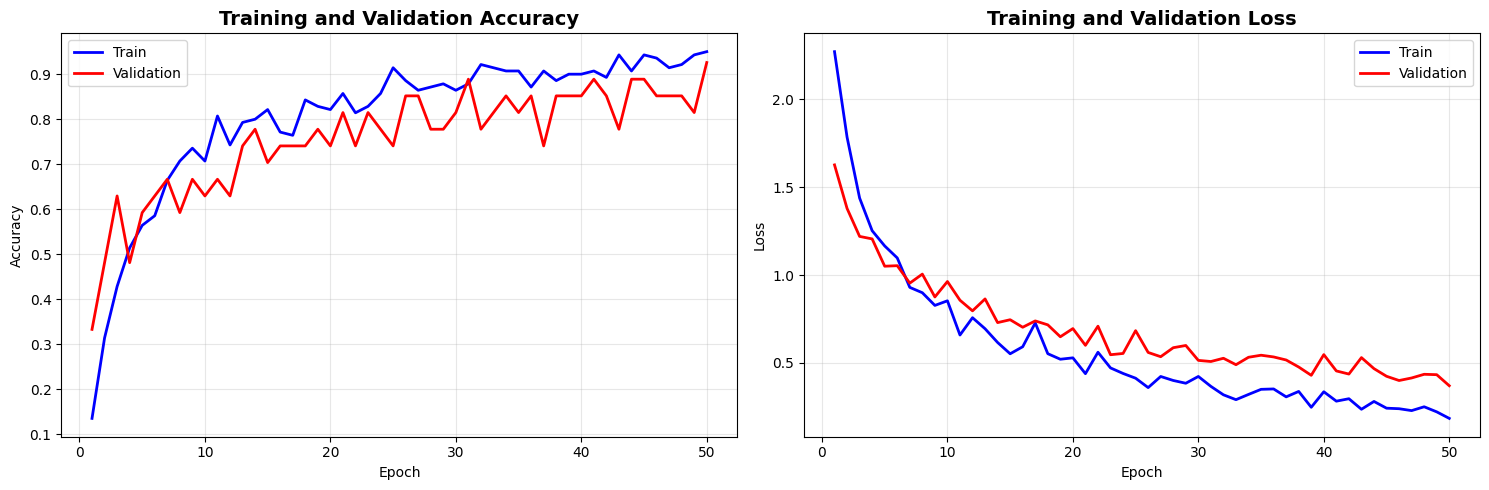


Final Training Accuracy   : 0.9500
Final Validation Accuracy : 0.9259
Best Validation Accuracy  : 0.9259  (epoch 50)
Final Training Loss       : 0.1841
Final Validation Loss     : 0.3699


In [ ]:
h = final_history.history
epoch_range = range(1, len(h['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epoch_range, h['accuracy'],     'b-', label='Train',      linewidth=2)
ax1.plot(epoch_range, h['val_accuracy'], 'r-', label='Validation', linewidth=2)
ax1.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax1.set(xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epoch_range, h['loss'],     'b-', label='Train',      linewidth=2)
ax2.plot(epoch_range, h['val_loss'], 'r-', label='Validation', linewidth=2)
ax2.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax2.set(xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy   : {h['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {h['val_accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy  : {max(h['val_accuracy']):.4f}  (epoch {h['val_accuracy'].index(max(h['val_accuracy']))+1})")
print(f"Final Training Loss       : {h['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {h['val_loss'][-1]:.4f}")


## Validation Set — Confusion Matrix and Classification Report

Validation accuracy: 25/27 (92.59%)



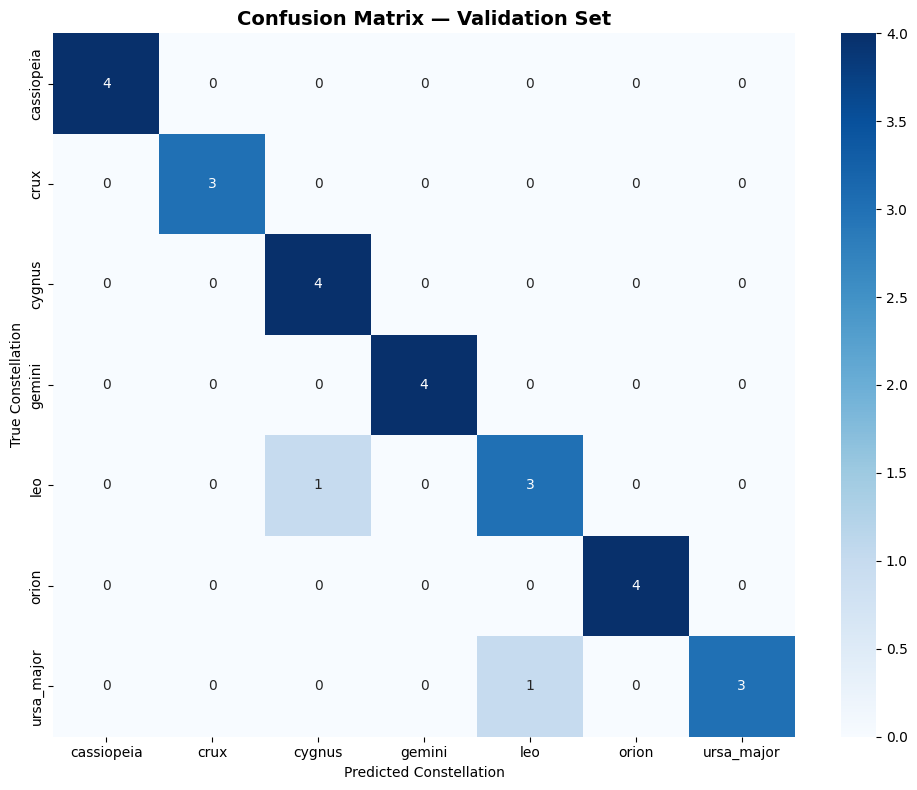


Classification Report — Validation Set
              precision    recall  f1-score   support

  cassiopeia       1.00      1.00      1.00         4
        crux       1.00      1.00      1.00         3
      cygnus       0.80      1.00      0.89         4
      gemini       1.00      1.00      1.00         4
         leo       0.75      0.75      0.75         4
       orion       1.00      1.00      1.00         4
  ursa_major       1.00      0.75      0.86         4

    accuracy                           0.93        27
   macro avg       0.94      0.93      0.93        27
weighted avg       0.93      0.93      0.93        27


Note: validation set has only 3 images per class.
Per-class F1 scores carry high variance at this scale.
See CV results above for statistically stable estimates.


In [ ]:
final_val_gen.reset()
val_preds = np.argmax(final_model.predict(final_val_gen, verbose=0), axis=1)
val_true  = final_val_gen.classes

correct = np.sum(val_preds == val_true)
print(f"Validation accuracy: {correct}/{len(val_true)} ({correct/len(val_true):.2%})\n")

plt.figure(figsize=(10, 8))
cm = confusion_matrix(val_true, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('True Constellation')
plt.xlabel('Predicted Constellation')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("Classification Report — Validation Set")
print(f"{'='*60}")
print(classification_report(val_true, val_preds, target_names=class_names))
print(f"\nNote: validation set has only {len(val_true)//num_classes} images per class.")
print("Per-class F1 scores carry high variance at this scale.")
print("See CV results above for statistically stable estimates.")


## Sample Predictions — Validation Set

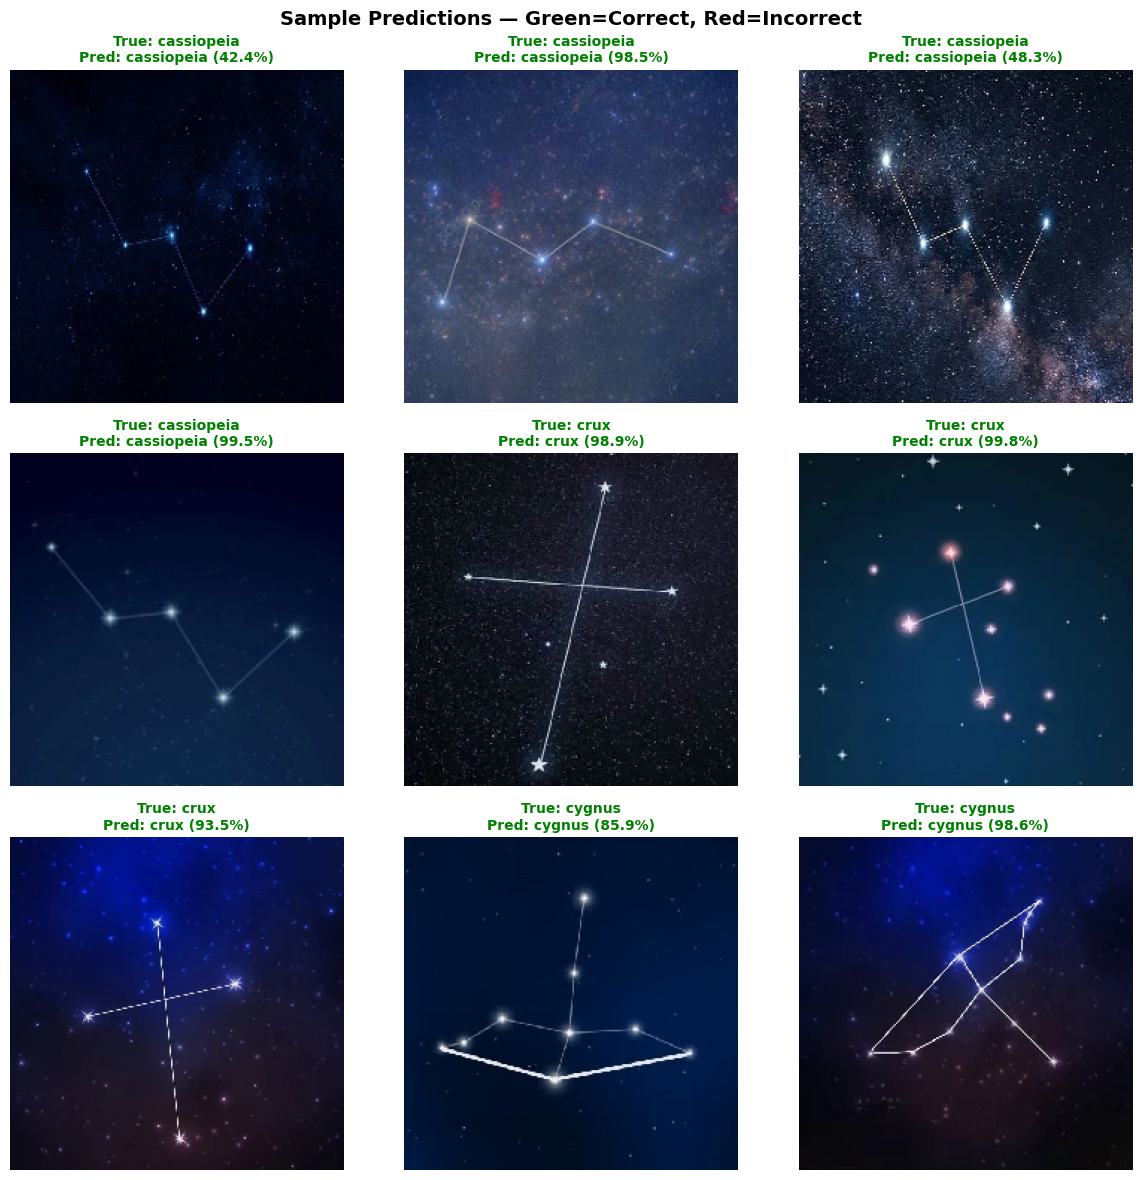

In [ ]:
final_val_gen.reset()
images_batch, labels_batch = next(final_val_gen)
sample_preds = final_model.predict(images_batch, verbose=0)

plt.figure(figsize=(12, 12))
for i in range(min(9, len(images_batch))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i])
    true_idx = np.argmax(labels_batch[i])
    pred_idx = np.argmax(sample_preds[i])
    conf     = sample_preds[i][pred_idx] * 100
    color    = 'green' if true_idx == pred_idx else 'red'
    plt.title(f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]} ({conf:.1f}%)",
              color=color, fontweight='bold', fontsize=10)
    plt.axis('off')

plt.suptitle('Sample Predictions — Green=Correct, Red=Incorrect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## ⭐ Final Evaluation on Held-Out Test Set


FINAL TEST SET EVALUATION
This cell should only be run ONCE, after all development is done.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step

  Test Accuracy  : 0.6000  (60.00%)
  Correct        : 21/35


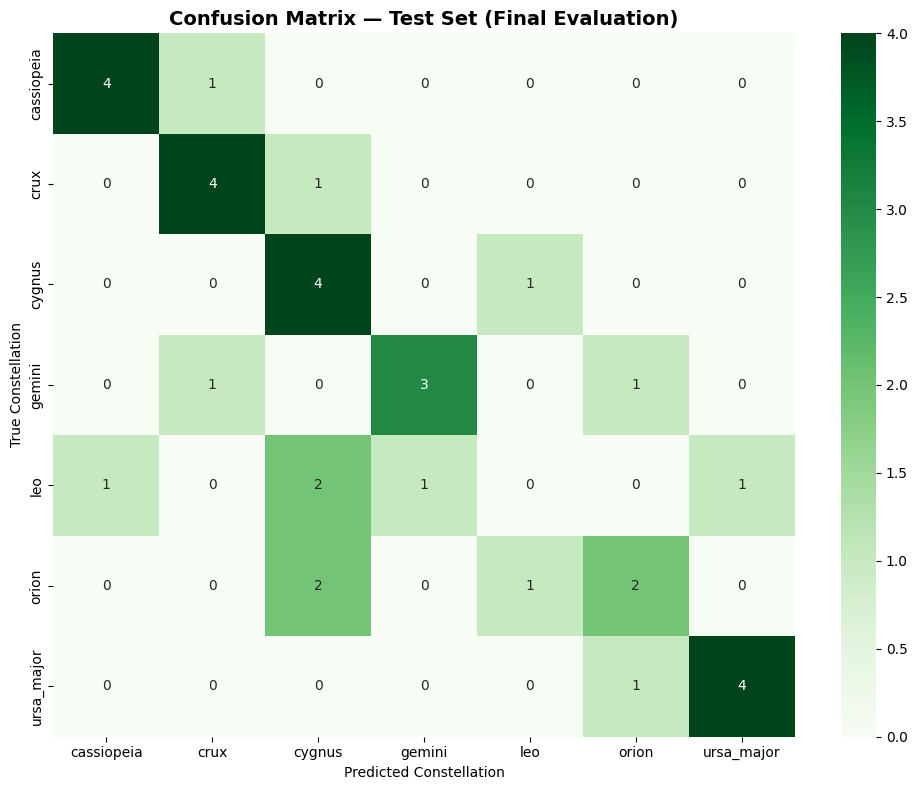


Classification Report — Test Set
              precision    recall  f1-score   support

  cassiopeia       0.80      0.80      0.80         5
        crux       0.67      0.80      0.73         5
      cygnus       0.44      0.80      0.57         5
      gemini       0.75      0.60      0.67         5
         leo       0.00      0.00      0.00         5
       orion       0.50      0.40      0.44         5
  ursa_major       0.80      0.80      0.80         5

    accuracy                           0.60        35
   macro avg       0.57      0.60      0.57        35
weighted avg       0.57      0.60      0.57        35


Paper-ready summary:
  MobileNetV2  |  Test Acc: 0.6000  |  Macro F1: 0.5728  |  Macro Prec: 0.5659  |  Macro Recall: 0.6000

✓ Test results saved to /content/drive/MyDrive/models/test_results.json


In [ ]:
print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("This cell should only be run ONCE, after all development is done.")
print("=" * 60)

test_generator.reset()
test_preds_probs = final_model.predict(test_generator, verbose=1)
test_preds = np.argmax(test_preds_probs, axis=1)
test_true  = test_generator.classes

test_acc = np.mean(test_preds == test_true)

print(f"\n{'='*60}")
print(f"  Test Accuracy  : {test_acc:.4f}  ({test_acc:.2%})")
print(f"  Correct        : {np.sum(test_preds == test_true)}/{len(test_true)}")
print(f"{'='*60}")

# Confusion matrix on test set
plt.figure(figsize=(10, 8))
cm_test = confusion_matrix(test_true, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set (Final Evaluation)', fontsize=14, fontweight='bold')
plt.ylabel('True Constellation')
plt.xlabel('Predicted Constellation')
plt.tight_layout()
plt.show()

# Full classification report
print(f"\n{'='*60}")
print("Classification Report — Test Set")
print(f"{'='*60}")
test_report = classification_report(test_true, test_preds,
                                     target_names=class_names, output_dict=True)
print(classification_report(test_true, test_preds, target_names=class_names))

# Summary table for paper
print("\nPaper-ready summary:")
print(f"  MobileNetV2  |  Test Acc: {test_acc:.4f}  |  "
      f"Macro F1: {test_report['macro avg']['f1-score']:.4f}  |  "
      f"Macro Prec: {test_report['macro avg']['precision']:.4f}  |  "
      f"Macro Recall: {test_report['macro avg']['recall']:.4f}")

# Save test results
test_results = {
    'test_accuracy': float(test_acc),
    'macro_f1': float(test_report['macro avg']['f1-score']),
    'macro_precision': float(test_report['macro avg']['precision']),
    'macro_recall': float(test_report['macro avg']['recall']),
    'per_class': {
        cls: {
            'precision': float(test_report[cls]['precision']),
            'recall': float(test_report[cls]['recall']),
            'f1-score': float(test_report[cls]['f1-score']),
        }
        for cls in class_names
    }
}
with open(os.path.join(MODEL_DIR, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=2)
print("\n✓ Test results saved to", os.path.join(MODEL_DIR, 'test_results.json'))


## Baseline CNN — Final Comparison


In [ ]:
print("Training Baseline CNN for comparison...")

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

baseline_train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=RANDOM_SEED
)
baseline_val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

baseline_model = create_baseline_cnn(num_classes, LEARNING_RATE)

cw_b = compute_class_weight(
    'balanced',
    classes=np.unique(baseline_train_gen.classes),
    y=baseline_train_gen.classes
)

baseline_model.fit(
    baseline_train_gen,
    epochs=EPOCHS,
    validation_data=baseline_val_gen,
    class_weight=dict(enumerate(cw_b)),
    callbacks=get_callbacks(),
    verbose=0
)

# Evaluate on test set
test_generator.reset()
baseline_preds = np.argmax(baseline_model.predict(test_generator, verbose=0), axis=1)
baseline_true  = test_generator.classes
baseline_acc   = np.mean(baseline_preds == baseline_true)
baseline_report = classification_report(baseline_true, baseline_preds,
                                         target_names=class_names, output_dict=True)

print("\n" + "="*60)
print("Model Comparison — Test Set Results")
print("="*60)
print(f"{'Model':<20} {'Accuracy':>10} {'Macro F1':>10} {'Macro Prec':>12} {'Macro Rec':>11}")
print("-"*60)
print(f"{'Baseline CNN':<20} {baseline_acc:>10.4f} "
      f"{baseline_report['macro avg']['f1-score']:>10.4f} "
      f"{baseline_report['macro avg']['precision']:>12.4f} "
      f"{baseline_report['macro avg']['recall']:>11.4f}")
print(f"{'MobileNetV2':<20} {test_results['test_accuracy']:>10.4f} "
      f"{test_results['macro_f1']:>10.4f} "
      f"{test_results['macro_precision']:>12.4f} "
      f"{test_results['macro_recall']:>11.4f}")
print("="*60)
print(f"\nImprovement (MobileNetV2 over Baseline):")
print(f"  Accuracy : +{(test_results['test_accuracy'] - baseline_acc)*100:.2f} pp")
print(f"  Macro F1 : +{(test_results['macro_f1'] - baseline_report['macro avg']['f1-score'])*100:.2f} pp")

# Save baseline results
baseline_results = {
    'test_accuracy': float(baseline_acc),
    'macro_f1': float(baseline_report['macro avg']['f1-score']),
    'macro_precision': float(baseline_report['macro avg']['precision']),
    'macro_recall': float(baseline_report['macro avg']['recall']),
}
with open(os.path.join(MODEL_DIR, 'baseline_results.json'), 'w') as f:
    json.dump(baseline_results, f, indent=2)
print("\n✓ Baseline results saved.")

Training Baseline CNN for comparison...
Found 140 images belonging to 7 classes.
Found 27 images belonging to 7 classes.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 42: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 47: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 47: early stopping
Restoring model weights from the end of the best epoch: 32.

Model Comparison — Test Set Results
Model                  Accuracy   Macro F1   Macro Prec   Macro Rec
------------------------------------------------------------
Baseline CNN             0.2857     0.2628       0.2738      0.2857
MobileNetV2              0.6000     0.5728       0.5659      0.6000

Improvement (MobileNetV2 over Baseline):
  Accuracy : +31.43 pp
  Macro F1 : +31.00 pp

✓ Baseline results saved.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Complete Results Summary — Paper-Ready Numbers

In [ ]:
print("=" * 65)
print("COMPLETE RESULTS SUMMARY FOR CONFERENCE PAPER")
print("=" * 65)

# CV results
for arch, res in cv_results.items():
    a = np.array(res['acc'])
    f = np.array(res['f1'])
    print(f"\n{arch} — 5-Fold Cross-Validation (train+val pool):")
    print(f"  Accuracy : {a.mean():.4f} ± {a.std():.4f}  "
          f"[95% CI: {a.mean()-1.96*a.std():.4f}–{a.mean()+1.96*a.std():.4f}]")
    print(f"  Macro F1 : {f.mean():.4f} ± {f.std():.4f}")

# Multi-seed
ma = np.array(seed_results['acc'])
mf = np.array(seed_results['f1'])
print(f"\nMobileNetV2 — Multi-Seed Runs ({N_SEEDS} seeds, val set):")
print(f"  Accuracy : {ma.mean():.4f} ± {ma.std():.4f}")
print(f"  Macro F1 : {mf.mean():.4f} ± {mf.std():.4f}")

# Final test
print(f"\nFinal Test Set Evaluation (one-time, held-out):")
print(f"  MobileNetV2  Accuracy  : {test_results['test_accuracy']:.4f}")
print(f"  MobileNetV2  Macro F1  : {test_results['macro_f1']:.4f}")
print(f"  Baseline CNN Accuracy  : {baseline_results['test_accuracy']:.4f}")
print(f"  Baseline CNN Macro F1  : {baseline_results['macro_f1']:.4f}")
print(f"  Transfer learning gain : +{(test_results['test_accuracy']-baseline_results['test_accuracy'])*100:.2f} pp accuracy")

print("=" * 65)


COMPLETE RESULTS SUMMARY FOR CONFERENCE PAPER

MobileNetV2 — 5-Fold Cross-Validation (train+val pool):
  Accuracy : 0.7367 ± 0.0425  [95% CI: 0.6534–0.8201]
  Macro F1 : 0.7338 ± 0.0536

Baseline CNN — 5-Fold Cross-Validation (train+val pool):
  Accuracy : 0.1740 ± 0.0363  [95% CI: 0.1028–0.2452]
  Macro F1 : 0.0863 ± 0.0492

MobileNetV2 — Multi-Seed Runs (5 seeds, val set):
  Accuracy : 0.8370 ± 0.0502
  Macro F1 : 0.8345 ± 0.0491

Final Test Set Evaluation (one-time, held-out):
  MobileNetV2  Accuracy  : 0.6000
  MobileNetV2  Macro F1  : 0.5728
  Baseline CNN Accuracy  : 0.2857
  Baseline CNN Macro F1  : 0.2628
  Transfer learning gain : +31.43 pp accuracy


## Save Final Model

In [ ]:
os.makedirs(MODEL_DIR, exist_ok=True)

model_path   = os.path.join(MODEL_DIR, "constellation_classifier.keras")
classes_path = os.path.join(MODEL_DIR, "classes.json")

final_model.save(model_path)
with open(classes_path, 'w') as f:
    json.dump(class_names, f)

print(f"✓ Model  saved → {model_path}")
print(f"✓ Classes saved → {classes_path}")
print()
print("To reload:")
print("  model = keras.models.load_model(model_path)")
print("  with open(classes_path) as f: class_names = json.load(f)")


✓ Model  saved → /content/drive/MyDrive/models/constellation_classifier.keras
✓ Classes saved → /content/drive/MyDrive/models/classes.json

To reload:
  model = keras.models.load_model(model_path)
  with open(classes_path) as f: class_names = json.load(f)
